In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [31]:
import pygad
import numpy as np
import torch
import os
from ga.components.ga import on_crossover_func, on_generation_func, calculate_dynamic_probs
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import pixel_cleaning_operation
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config

In [32]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [33]:
config = load_config()

In [34]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [35]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [36]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [37]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [38]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config


Generation 1 completed with fitness: [-3.87862691 -3.85024557 -3.81980428 -3.8213912  -3.8098174  -3.84425191
 -3.83091573 -3.84094839 -3.86013326 -3.80014791 -3.85741872 -3.78639211
 -3.81456747 -3.84803762 -3.91958761 -3.85674734 -3.87176961 -3.82156209
 -3.78171377 -3.78202199 -3.87792348 -3.82613058 -3.86742849 -3.7580718
 -3.83829183 -3.84252767 -3.82673482 -3.88194265 -3.83868093 -3.80908193
 -3.79699697 -3.87479848 -3.85381002 -3.83611593 -3.81146993 -3.81818075
 -3.83188314 -3.88210287 -3.84776296 -3.81530294 -3.86495656 -3.75337972
 -3.84009695 -3.87446584 -3.82823781 -3.79969015 -3.84777059 -3.8680129
 -3.84368886 -3.90457448]
Best Fitness = -3.7533797209042374

Best solution snippet: [ 0.0321334  -0.49088121  0.20668079 -0.05580106 -0.13712261  0.30627687
 -0.25093162  0.02897699  0.42255424  0.02016754]
Best solution zeros count: 15090
Best perturbation magnitude: 105.95591735839844
Visualizing


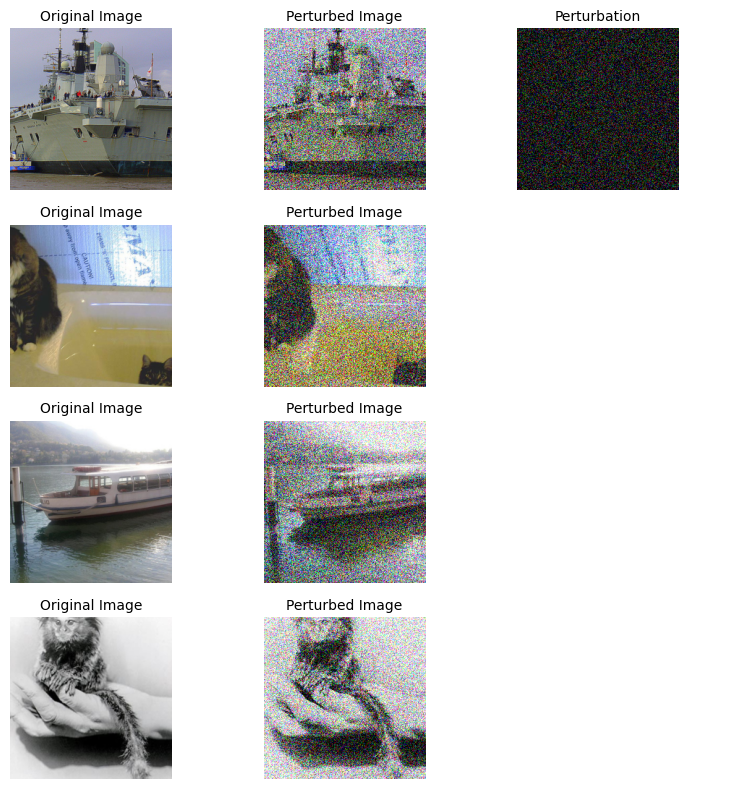

New crossover & mutation probabilities: 0.8921875, 0.59375

Generation 2 completed with fitness: [-2.94553046 -2.93472571 -2.99771705 -2.99196143 -3.00238471 -2.96081824
 -2.98240027 -2.98471046 -2.94976935 -2.99154334 -2.93935523 -3.0000669
 -3.00642676 -3.03258338 -2.94491248 -2.99158149 -2.96820197 -2.95821052
 -3.0057508  -3.04459662 -2.97911963 -2.98907599 -2.97205482 -2.95315681
 -2.98599219 -3.00435309 -2.96685157 -2.99446692 -2.94682136 -2.9441587
 -2.97602057 -2.90516486 -3.02487159 -2.92832923 -2.99584022 -2.92566199
 -2.97192206 -2.97115607 -2.96707892 -2.94173255 -2.93028846 -2.9874433
 -2.93598456 -2.95321479 -2.94629188 -2.96637397 -2.95376563 -2.98189063
 -2.95704169 -2.95716987]
New batch loaded with first label: 333
Best Fitness = -2.882412481399294

Best solution snippet: [ 0.0321334   0.         -0.37637123 -0.05580106  0.43585092 -0.25406224
  0.1701162   0.332963   -0.02912915 -0.09003776]
Best solution zeros count: 28717
Best perturbation magnitude: 100.4468688964

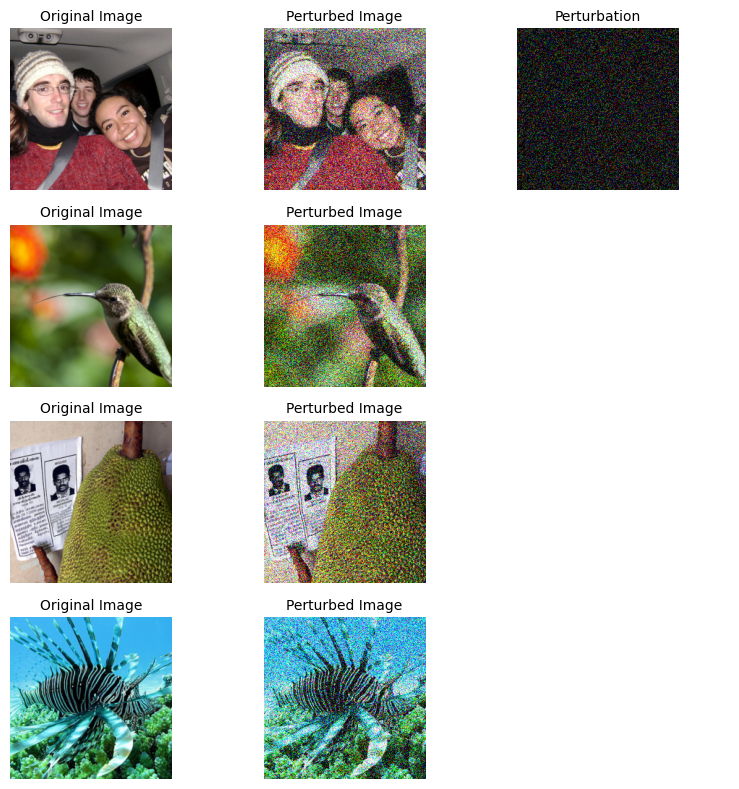

New crossover & mutation probabilities: 0.884375, 0.5875

Generation 3 completed with fitness: [-2.09266023 -2.20293397 -2.17448244 -2.15466432 -2.18742647 -2.22271547
 -2.19944734 -2.18456697 -2.17799348 -2.15851106 -2.17773561 -2.20997896
 -2.15831575 -2.11562929 -2.15789918 -2.20634126 -2.12612581 -2.1769803
 -2.16811342 -2.09653139 -2.1554593  -2.17165346 -2.12053804 -2.10048036
 -2.20473146 -2.17679719 -2.16512422 -2.08685731 -2.12500429 -2.07501192
 -2.12552614 -2.14706239 -2.21286134 -2.13250703 -2.18431978 -2.12335634
 -2.179144   -2.18405275 -2.13024568 -2.12850313 -2.19361543 -2.08912019
 -2.11761751 -2.17613496 -2.14926423 -2.12537813 -2.13468599 -2.12583894
 -2.16678438 -2.11477785]
Best Fitness = -2.0750119156598745

Best solution snippet: [-0.23341915 -0.49088121 -0.1067846  -0.05580106 -0.13712261  0.
  0.          0.          0.          0.        ]
Best solution zeros count: 41303
Best perturbation magnitude: 95.1934585571289
Visualizing


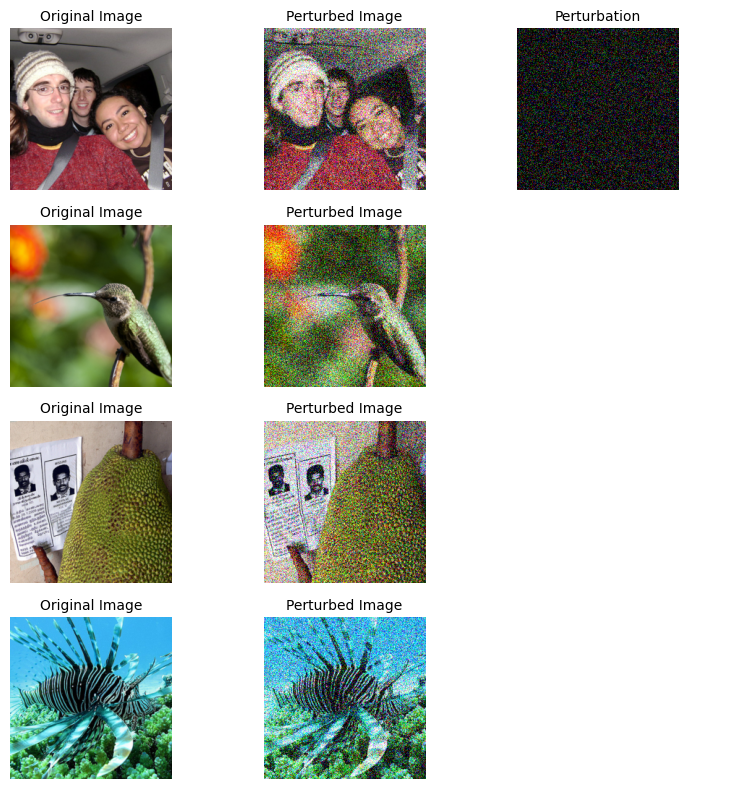

New crossover & mutation probabilities: 0.8765625, 0.5812499999999999

Generation 4 completed with fitness: [-1.41269609 -1.41184465 -1.36093828 -1.38422624 -1.45766374 -1.399778
 -1.39724809 -1.41915971 -1.40558702 -1.42302171 -1.40881273 -1.40037156
 -1.43104631 -1.39996873 -1.3982567  -1.41906206 -1.37717821 -1.3535637
 -1.38375627 -1.41590501 -1.40142595 -1.38959581 -1.3577736  -1.4580803
 -1.40238267 -1.45122148 -1.39068834 -1.4140999  -1.33933183 -1.45793687
 -1.3911873  -1.39562608 -1.41908952 -1.42360612 -1.41373674 -1.40465623
 -1.31695939 -1.4330269  -1.41892473 -1.41201707 -1.42407152 -1.42244188
 -1.36703721 -1.38479234 -1.39786607 -1.34005815 -1.42835618 -1.36160356
 -1.352343   -1.40446245]
New batch loaded with first label: 461
Best Fitness = -1.2075843941022357

Best solution snippet: [ 0.0321334   0.14243072 -0.1067846   0.          0.         -0.25729967
 -0.00169167  0.         -0.19434582  0.02016754]
Best solution zeros count: 52087
Best perturbation magnitude: 90.

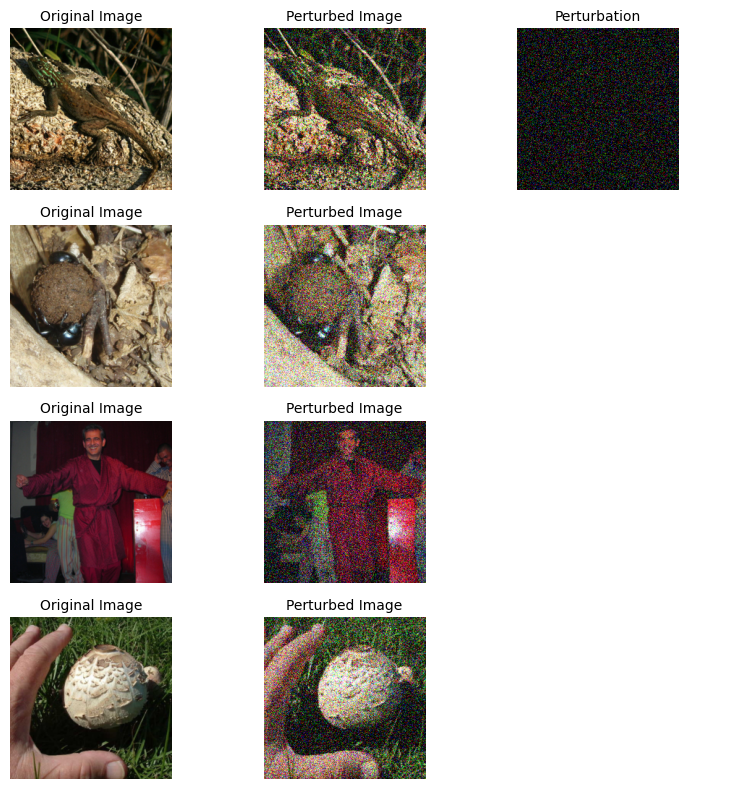

New crossover & mutation probabilities: 0.86875, 0.575

Generation 5 completed with fitness: [-0.62341496 -0.63335453 -0.62660862 -0.65825382 -0.55719486 -0.57563511
 -0.68308903 -0.6037479  -0.5775684  -0.61207615 -0.61392552 -0.61651341
 -0.60899235 -0.66047093 -0.6044788  -0.58903233 -0.60056187 -0.59772068
 -0.60493199 -0.64888798 -0.52564732 -0.58317295 -0.5510059  -0.56946293
 -0.62616459 -0.66693302 -0.61307102 -0.6104282  -0.56698338 -0.63187748
 -0.55871617 -0.53494145 -0.60748783 -0.54152714 -0.55888249 -0.63262211
 -0.58205754 -0.57364689 -0.59081455 -0.57843815 -0.62028538 -0.62579075
 -0.64273106 -0.57021061 -0.57154576 -0.59400059 -0.61304814 -0.58524815
 -0.63300205 -0.6183231 ]
Best Fitness = -0.5256473179284997

Best solution snippet: [ 0.2286867   0.14243072  0.          0.         -0.13712261 -0.25729967
  0.          0.09146007  0.          0.        ]
Best solution zeros count: 61533
Best perturbation magnitude: 85.91992950439453
Visualizing


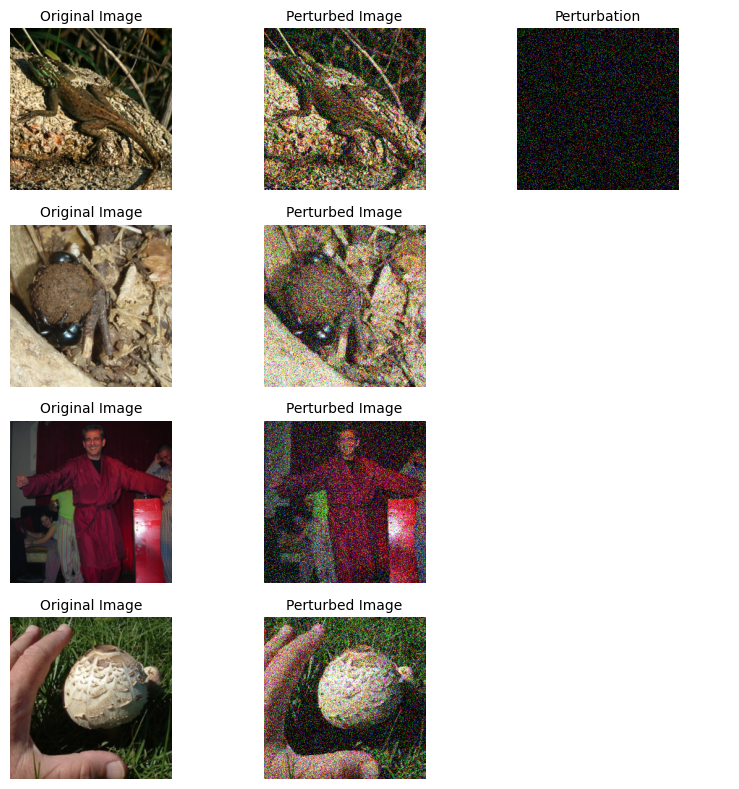

New crossover & mutation probabilities: 0.8609375, 0.56875

Generation 6 completed with fitness: [ 0.04966605  0.02768271  0.01944602  0.04712394 -0.02393472  0.01624015
  0.13525718  0.07500022  0.08536551 -0.01114175  0.12310508  0.10047782
  0.03598349  0.08202689  0.08282035  0.1258364   0.02502768  0.05258353
  0.04889701  0.07185843  0.10411857  0.09149497  0.0778292   0.02127402
  0.0371569   0.09588797  0.05908072  0.06632254  0.05968192  0.06426719
  0.08038352  0.06322043  0.10032218  0.08606437  0.05679953  0.01864341
  0.03379691  0.0800936  -0.02647531 -0.00019815  0.0712786   0.07808555
  0.01623099  0.07723258  0.03214744  0.10493796  0.11576713  0.03825248
  0.06608909  0.05341208]
New batch loaded with first label: 42
Best Fitness = -0.05525948630908606

Best solution snippet: [-0.23341915 -0.49088121 -0.1067846   0.46900369  0.          0.
 -0.00169167  0.02897699  0.          0.07558582]
Best solution zeros count: 70401
Best perturbation magnitude: 81.3823013305664
V

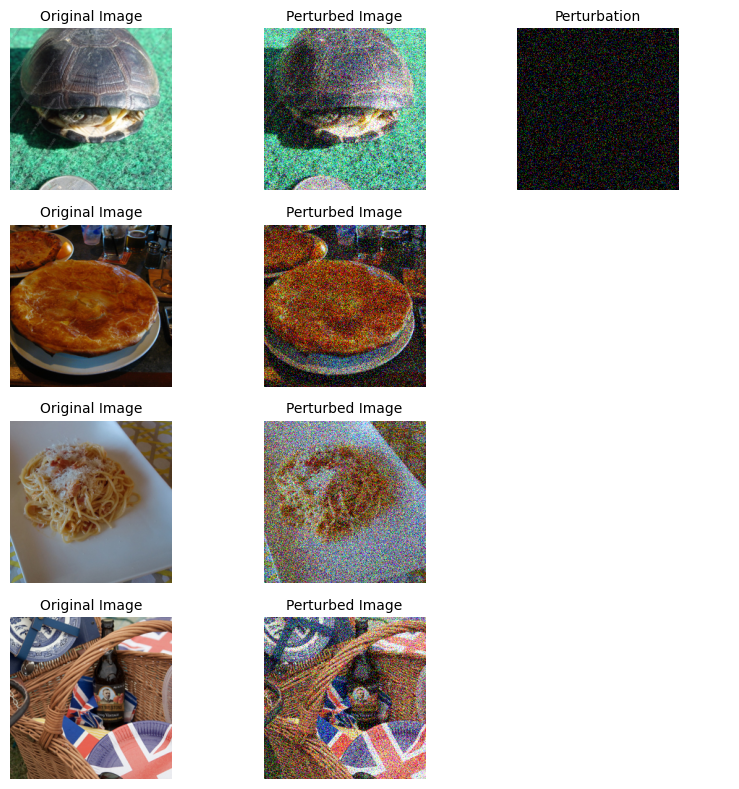

New crossover & mutation probabilities: 0.853125, 0.5625

Generation 7 completed with fitness: [0.44960646 0.49570784 0.48190169 0.5073213  0.5161302  0.546875
 0.51186537 0.5625     0.46454634 0.50312361 0.48092055 0.50267653
 0.5262773  0.49527144 0.5361421  0.52917494 0.546875   0.47296919
 0.48536848 0.50126814 0.48424238 0.55352339 0.53125    0.49394697
 0.47352308 0.52400526 0.42316603 0.48182539 0.49505934 0.49905256
 0.50498213 0.48751387 0.54358839 0.47996077 0.50680098 0.51765608
 0.578125   0.53994307 0.55457319 0.56754469 0.51969313 0.50132918
 0.50220503 0.51481795 0.546875   0.51262831 0.49070448 0.48994765
 0.51058974 0.47969984]


KeyboardInterrupt: 

In [62]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["p_crossover_init"],
    mutation_type=lambda ga_inst, offspring: paper_style_mutation(ga_inst, offspring, config["mutation"]["p_mutation_init"], config["mutation"]["p_flip"]),
    fitness_func=lambda ga_inst, solution, solution_idx: constrained_fitness_func(
        ga_inst, solution, solution_idx, model, config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    ),
    on_generation=lambda ga_inst: on_generation_func(ga_inst, dataloader, device, top_perturbations, config),
    on_crossover=lambda ga_inst, offspring: on_crossover_func(ga_inst, offspring, config),
)

ga_instance.user_data={
    "input_batch": input_batch,
    "labels": labels
}

ga_instance.run()

In [46]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [52]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.5625


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


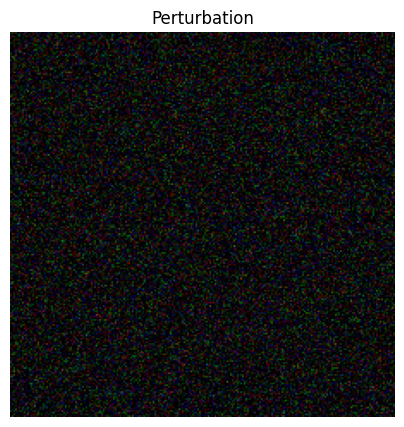

In [140]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

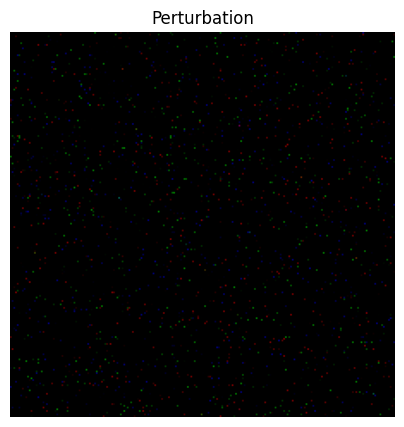

In [53]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[-1]
visualize_perturbation(universal_perturbation)

# Metrics
(takes a while)

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [54]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.41226


0.41226

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)